# MLP para Classificação de Batimentos Cardíacos (v2)

## Ir Além 2a - Diagnóstico Visual em Cardiologia com Rede Neural

Este notebook implementa uma rede neural MLP (Perceptron Multicamadas) com Keras
para classificação binária de batimentos cardíacos: **normal vs. anormal**.

### Versão 2 — Correções do modelo v1

O modelo v1 (`mlp_heartbeat_v1.ipynb`) atingiu apenas 5.17% de recall na classe
Anormal — praticamente não detectava arritmias. A análise de falha
(`docs/raciocinio/mlp-heartbeat/08-analise-falha-v1.md`) identificou a causa raiz:
o `validation_split` do Keras extraía uma fatia não-representativa das últimas 15%
do CSV ordenado, causando early stopping prematuro na época 6.

A correção principal do v2 embaralha os dados antes do treino. Correções adicionais:
learning rate reduzida (0.0005) e patience aumentada (10 épocas).

### Pipeline

1. Carregamento do dataset MIT-BIH Heartbeat
2. Pré-processamento: binarização, **embaralhamento** (correção v2), class_weight
3. Análise exploratória: distribuição de classes, visualização de sinais
4. Construção da MLP com Keras (Sequential, Dense, BatchNorm, Dropout)
5. Treinamento com class_weight e early stopping (patience=10)
6. Avaliação: acurácia, precision, recall, F1, matriz de confusão

| Propriedade | Valor |
|-------------|-------|
| Origem | [Kaggle - shayanfazeli/heartbeat](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) |
| Treino | 87.554 batimentos |
| Teste | 21.892 batimentos |
| Features | 187 amostras do sinal ECG |
| Classes | Normal (0) vs. Anormal (1) |

## Nota sobre mensagens de log do TensorFlow

Ao importar o TensorFlow, duas mensagens aparecem no `stderr` e **não
indicam erro** nem afetam os resultados numéricos da rede:

### `WARNING: All log messages before absl::InitializeLog() is called are written to STDERR`

Emitida pelo binário compilado do TensorFlow durante o bootstrap da
biblioteca `absl` do Google, antes do interpretador Python obter controle.
Nenhum código do usuário executa antes dela. É um problema conhecido do
upstream TensorFlow rastreado no [issue 62075](https://github.com/tensorflow/tensorflow/issues/62075),
ainda sem correção. Não há ajuste em Python que a elimine.

### `oneDNN custom operations are on. You may see slightly different numerical results...`

Notificação informativa (nível `INFO`) emitida em `port.cc:153` anunciando
que as otimizações oneDNN estão habilitadas — comportamento padrão do
TensorFlow em CPU e GPU a partir da versão 2.9. O aviso menciona pequenas
variações de arredondamento de ponto flutuante decorrentes de reordenação
de operações vetorizadas — irrelevantes para a precisão da classificação
binária deste modelo. Desativá-las via `TF_ENABLE_ONEDNN_OPTS=0`
degradaria a performance do treino sem benefício real.

### Decisão

Nenhuma das duas mensagens é suprimida neste notebook. Suprimí-las via
`TF_CPP_MIN_LOG_LEVEL=3` ocultaria também eventuais erros legítimos
durante o treino — trocaria diagnóstico por silêncio, o que contraria
boa prática de engenharia. A mensagem `Could not find cuda drivers`,
que sim indicava ausência de aceleração por GPU, foi **corrigida** pela
instalação do driver NVIDIA e das bibliotecas CUDA — não suprimida.


In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.21.0
NumPy: 2.4.3
Pandas: 3.0.1


## 1. Carregamento do dataset

| Classe | Código AAMI | Treino | % |
|--------|-------------|--------|---|
| 0 | Normal (N) | 72.471 | 82.8% |
| 1 | Supraventricular (S) | 2.223 | 2.5% |
| 2 | Ventricular (V) | 5.788 | 6.6% |
| 3 | Fusão (F) | 641 | 0.7% |
| 4 | Desconhecido (Q) | 6.431 | 7.3% |

In [2]:
CAMINHO_TREINO = "../data/numericos/heartbeat/mitbih_train.csv"
CAMINHO_TESTE = "../data/numericos/heartbeat/mitbih_test.csv"

df_treino = pd.read_csv(CAMINHO_TREINO, header=None)
df_teste = pd.read_csv(CAMINHO_TESTE, header=None)

print(f"Treino: {df_treino.shape[0]:,} amostras, {df_treino.shape[1]} colunas")
print(f"Teste:  {df_teste.shape[0]:,} amostras, {df_teste.shape[1]} colunas")

X_treino = df_treino.iloc[:, :-1].values
y_treino_original = df_treino.iloc[:, -1].values.astype(int)
X_teste = df_teste.iloc[:, :-1].values
y_teste_original = df_teste.iloc[:, -1].values.astype(int)

print(f"\nFeatures: {X_treino.shape[1]} amostras do sinal por batimento")
print(f"Range dos valores: [{X_treino.min():.4f}, {X_treino.max():.4f}]")

Treino: 87,554 amostras, 188 colunas
Teste:  21,892 amostras, 188 colunas

Features: 187 amostras do sinal por batimento
Range dos valores: [0.0000, 1.0000]


## 2. Pré-processamento

### Binarização e embaralhamento (correção v2)

O modelo v1 não embaralhava os dados antes do `validation_split`. O Keras extrai
as **últimas** N% do array como validação. No MIT-BIH, batimentos do mesmo paciente
são consecutivos no CSV — as últimas 15% continham uma distribuição de classes
diferente do restante, causando monitoramento de validação enviesado e early
stopping prematuro na época 6.

O v2 embaralha os dados com `np.random.permutation` antes de qualquer operação,
garantindo que o `validation_split` do Keras extrai uma fatia representativa.

In [3]:
# binarizar: Normal (0) vs Anormal (1)
y_treino = (y_treino_original > 0).astype(int)
y_teste = (y_teste_original > 0).astype(int)

# CORREÇÃO V2: embaralhar dados antes do treino
np.random.seed(42)
indices = np.random.permutation(len(X_treino))
X_treino = X_treino[indices]
y_treino = y_treino[indices]

print("Distribuição após binarização:")
print(f"\nTreino:")
for c, nome in [(0, "Normal"), (1, "Anormal")]:
    n = (y_treino == c).sum()
    print(f"  {nome}: {n:>6,} ({n/len(y_treino)*100:.1f}%)")

print(f"\nTeste:")
for c, nome in [(0, "Normal"), (1, "Anormal")]:
    n = (y_teste == c).sum()
    print(f"  {nome}: {n:>6,} ({n/len(y_teste)*100:.1f}%)")

# class_weight
pesos_classes = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_treino)
class_weight = {0: pesos_classes[0], 1: pesos_classes[1]}
print(f"\nPesos das classes (class_weight):")
print(f"  Normal (0):  {class_weight[0]:.4f}")
print(f"  Anormal (1): {class_weight[1]:.4f}")

Distribuição após binarização:

Treino:
  Normal: 72,471 (82.8%)
  Anormal: 15,083 (17.2%)

Teste:
  Normal: 18,118 (82.8%)
  Anormal:  3,774 (17.2%)

Pesos das classes (class_weight):
  Normal (0):  0.6041
  Anormal (1): 2.9024


## 3. Visualização de batimentos

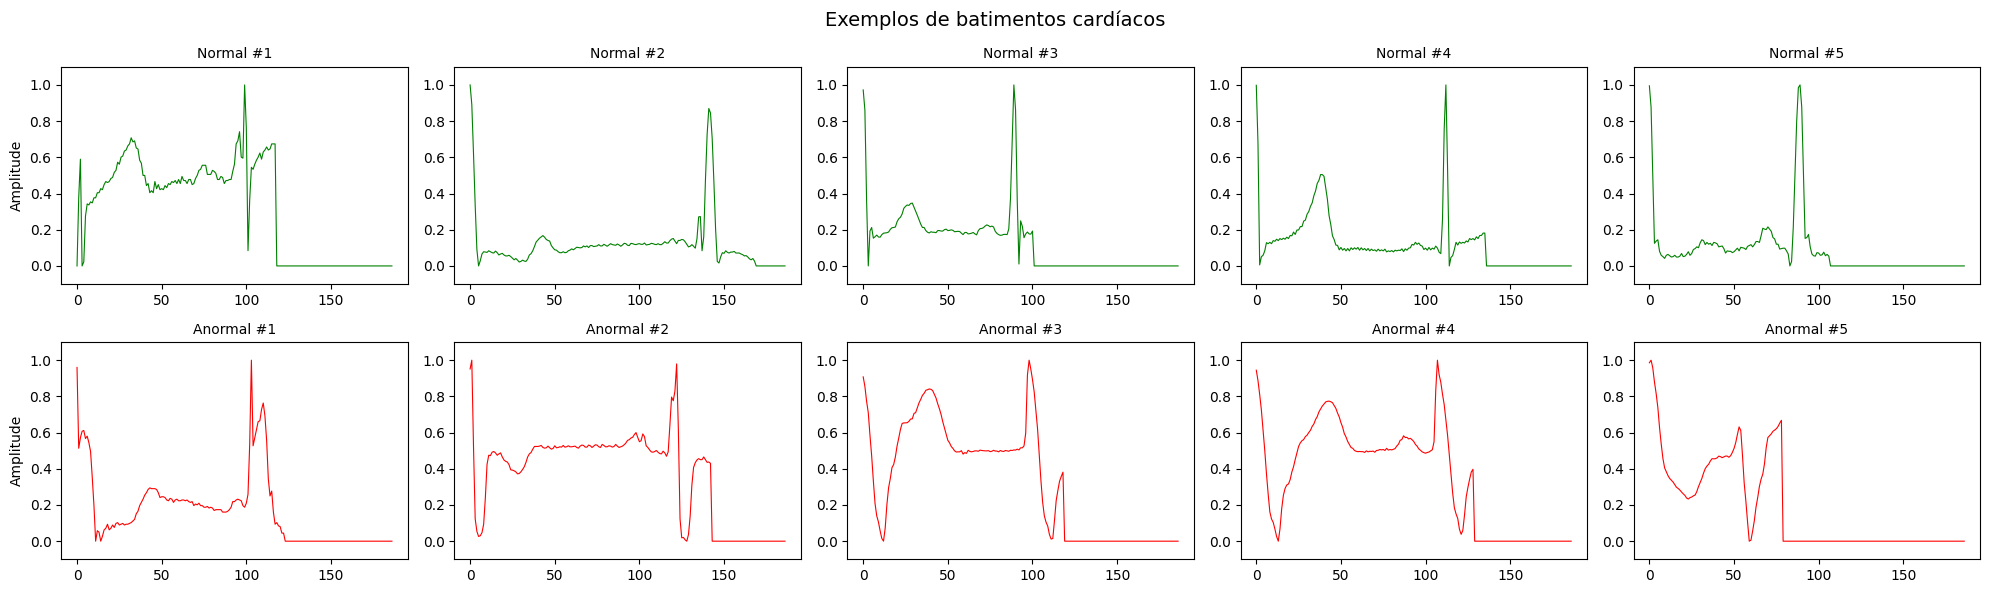

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
fig.suptitle("Exemplos de batimentos cardíacos", fontsize=14)
np.random.seed(42)
idx_normal = np.where(y_treino == 0)[0]
idx_anormal = np.where(y_treino == 1)[0]

for i in range(5):
    ax = axes[0, i]
    idx = np.random.choice(idx_normal)
    ax.plot(X_treino[idx], color="green", linewidth=0.8)
    ax.set_title(f"Normal #{i+1}", fontsize=10)
    ax.set_ylim(-0.1, 1.1)
    if i == 0: ax.set_ylabel("Amplitude")

    ax = axes[1, i]
    idx = np.random.choice(idx_anormal)
    ax.plot(X_treino[idx], color="red", linewidth=0.8)
    ax.set_title(f"Anormal #{i+1}", fontsize=10)
    ax.set_ylim(-0.1, 1.1)
    if i == 0: ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.savefig("batimentos_exemplo.png", dpi=150, bbox_inches="tight")
plt.show()

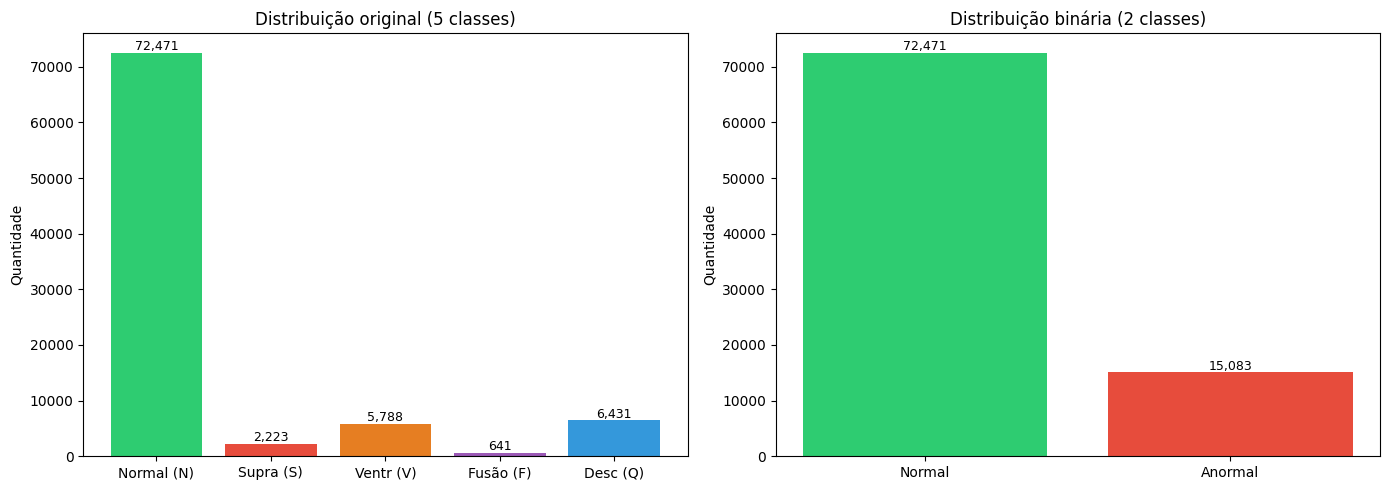

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nomes_orig = ["Normal (N)", "Supra (S)", "Ventr (V)", "Fusão (F)", "Desc (Q)"]
contagens_orig = [np.sum(y_treino_original[indices] == c) for c in range(5)]
cores_orig = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6", "#3498db"]
axes[0].bar(nomes_orig, contagens_orig, color=cores_orig)
axes[0].set_title("Distribuição original (5 classes)")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(contagens_orig):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

nomes_bin = ["Normal", "Anormal"]
contagens_bin = [(y_treino == 0).sum(), (y_treino == 1).sum()]
cores_bin = ["#2ecc71", "#e74c3c"]
axes[1].bar(nomes_bin, contagens_bin, color=cores_bin)
axes[1].set_title("Distribuição binária (2 classes)")
axes[1].set_ylabel("Quantidade")
for i, v in enumerate(contagens_bin):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Construção da MLP (v2)

### Alterações em relação ao v1

| Parâmetro | v1 | v2 | Razão |
|-----------|----|----|-------|
| Embaralhamento | Não | Sim | Validação representativa |
| Learning rate | 0.001 | 0.0005 | Convergência mais estável |
| Early stopping patience | 5 | 10 | Evitar interrupção prematura |
| Arquitetura | 128-64-32 + BatchNorm + Dropout | Idêntica | A arquitetura não era o problema |

In [6]:
def construir_mlp(input_dim: int) -> keras.Model:
    modelo = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # v2: reduzida
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return modelo

tf.random.set_seed(42)
modelo = construir_mlp(X_treino.shape[1])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 34,881 (136.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Treinamento (v2)

In [7]:
EPOCAS = 50
BATCH_SIZE = 256

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,  # v2: aumentado de 5 para 10
    restore_best_weights=True,
    verbose=1,
)

historico = modelo.fit(
    X_treino, y_treino,
    epochs=EPOCAS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1,
)

print(f"\nTreinamento encerrado na época {len(historico.history['loss'])}")
print(f"Melhor val_loss: {min(historico.history['val_loss']):.4f}")
print(f"Melhor val_accuracy: {max(historico.history['val_accuracy']):.4f}")

Epoch 1/50


  1/291 ━━━━━━━━━━━━━━━━━━━━ 23:44 5s/step - accuracy: 0.4727 - loss: 0.8826

 48/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5492 - loss: 0.7030  

 94/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5842 - loss: 0.6462

144/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6120 - loss: 0.6083

...

182/291 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.9669 - loss: 0.0957

242/291 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.9669 - loss: 0.0961

291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9675 - loss: 0.0958 - val_accuracy: 0.9692 - val_loss: 0.0891


Restoring model weights from the end of the best epoch: 43.



Treinamento encerrado na época 50
Melhor val_loss: 0.0751
Melhor val_accuracy: 0.9753


## 6. Curvas de treinamento

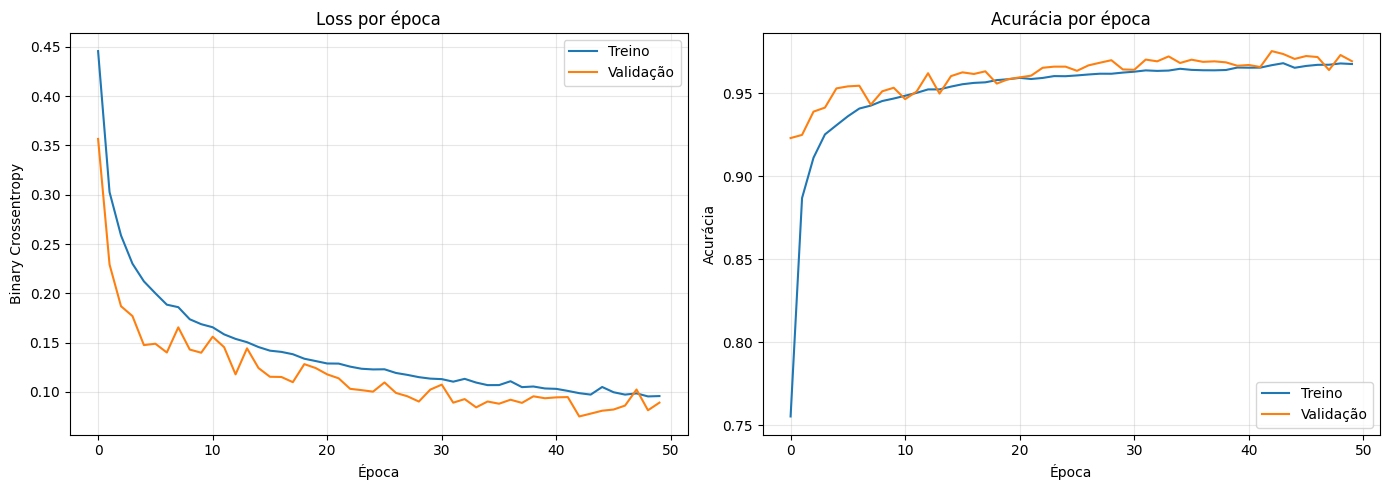

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(historico.history["loss"], label="Treino")
axes[0].plot(historico.history["val_loss"], label="Validação")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historico.history["accuracy"], label="Treino")
axes[1].plot(historico.history["val_accuracy"], label="Validação")
axes[1].set_title("Acurácia por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("curvas_treinamento.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Avaliação no conjunto de teste

In [9]:
y_pred_prob = modelo.predict(X_teste, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=" * 60)
print("AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 60)
print(f"\nAmostras de teste: {len(y_teste):,}")
print(f"\n{classification_report(y_teste, y_pred, target_names=['Normal', 'Anormal'])}")
acuracia = (y_pred == y_teste).mean()
print(f"Acurácia geral: {acuracia:.4f}")

AVALIAÇÃO NO CONJUNTO DE TESTE

Amostras de teste: 21,892

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98     18118
     Anormal       0.91      0.94      0.93      3774

    accuracy                           0.97     21892
   macro avg       0.95      0.96      0.95     21892
weighted avg       0.97      0.97      0.97     21892

Acurácia geral: 0.9740


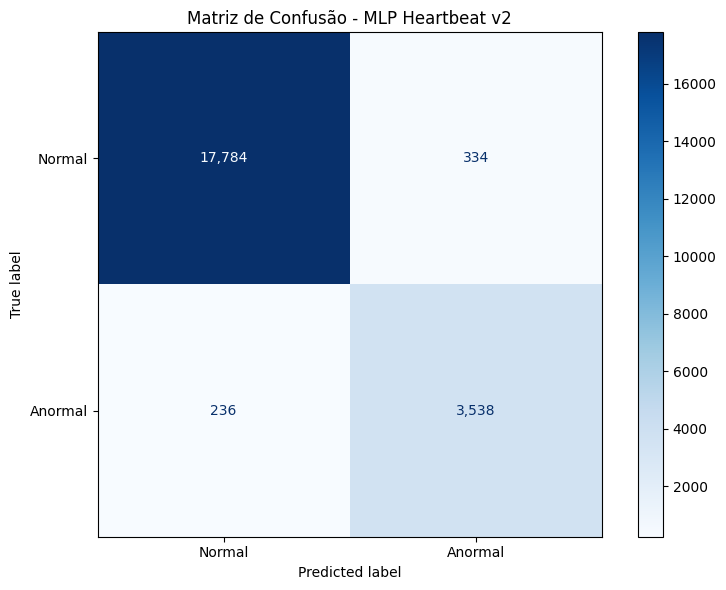

Verdadeiros Negativos (Normal correto):  17,784
Falsos Positivos (Normal -> Anormal):        334
Falsos Negativos (Anormal -> Normal):        236
Verdadeiros Positivos (Anormal correto):  3,538

Taxa de Falsos Negativos: 6.25%
Taxa de Falsos Positivos: 1.84%


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_teste, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anormal"])
disp.plot(ax=ax, cmap="Blues", values_format=",d")
ax.set_title("Matriz de Confusão - MLP Heartbeat v2")
plt.tight_layout()
plt.savefig("matriz_confusao_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros Negativos (Normal correto):  {tn:>6,}")
print(f"Falsos Positivos (Normal -> Anormal):     {fp:>6,}")
print(f"Falsos Negativos (Anormal -> Normal):     {fn:>6,}")
print(f"Verdadeiros Positivos (Anormal correto): {tp:>6,}")
print(f"\nTaxa de Falsos Negativos: {fn/(fn+tp)*100:.2f}%")
print(f"Taxa de Falsos Positivos: {fp/(fp+tn)*100:.2f}%")

## 8. Análise por classe original

In [11]:
print("Recall por classe original do MIT-BIH:")
print("-" * 50)
nomes_classes = {0: "Normal (N)", 1: "Supraventricular (S)", 2: "Ventricular (V)",
                 3: "Fusão (F)", 4: "Desconhecido (Q)"}
for classe in range(5):
    mascara = y_teste_original == classe
    if mascara.sum() == 0: continue
    preds_classe = y_pred[mascara]
    corretos = (preds_classe == 0).sum() if classe == 0 else (preds_classe == 1).sum()
    total = mascara.sum()
    recall = corretos / total
    print(f"  {nomes_classes[classe]:25s}: {corretos:>5,}/{total:>5,} = {recall:.3f}")

Recall por classe original do MIT-BIH:
--------------------------------------------------
  Normal (N)               : 17,784/18,118 = 0.982
  Supraventricular (S)     :   413/  556 = 0.743
  Ventricular (V)          : 1,401/1,448 = 0.968
  Fusão (F)                :   133/  162 = 0.821
  Desconhecido (Q)         : 1,591/1,608 = 0.989


## 9. Comparação v1 vs v2

In [12]:
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(y_teste, y_pred, average="macro")
_, rec_por_classe, _, _ = precision_recall_fscore_support(y_teste, y_pred, average=None)

print("COMPARAÇÃO V1 vs V2")
print("=" * 60)
print(f"{'Métrica':25s} {'v1':>10s} {'v2':>10s} {'Melhoria':>12s}")
print("-" * 60)

comparacoes = [
    ("Recall Anormal", 0.0323, rec_por_classe[1]),
    ("F1-macro", 0.4855, f1),
    ("Acurácia", 0.8331, acuracia),
    ("Taxa FN", 96.77, fn/(fn+tp)*100),
]
for nome, v1, v2 in comparacoes:
    if nome == "Taxa FN":
        melhoria = f"{v1/v2:.0f}x redução" if v2 > 0 else "inf"
    else:
        melhoria = f"{v2/v1:.1f}x" if v1 > 0 else "inf"
    print(f"  {nome:23s} {v1:>10.3f} {v2:>10.3f} {melhoria:>12s}")

print(f"\nCausa raiz da falha v1: validation_split sobre dados não embaralhados")
print(f"Correção principal v2: np.random.permutation antes do fit()")

print(f"\nRESUMO DO MODELO V2")
print("=" * 60)
print(f"Arquitetura: MLP 128-64-32 + BatchNorm + Dropout")
print(f"Parâmetros: {modelo.count_params():,}")
print(f"Épocas treinadas: {len(historico.history['loss'])}")
print(f"Learning rate: 0.0005 (v1: 0.001)")
print(f"Early stopping patience: 10 (v1: 5)")
print(f"Dados embaralhados: Sim (v1: Não)")

COMPARAÇÃO V1 vs V2
Métrica                           v1         v2     Melhoria
------------------------------------------------------------
  Recall Anormal               0.032      0.937        29.0x
  F1-macro                     0.485      0.955         2.0x
  Acurácia                     0.833      0.974         1.2x
  Taxa FN                     96.770      6.253  15x redução

Causa raiz da falha v1: validation_split sobre dados não embaralhados
Correção principal v2: np.random.permutation antes do fit()

RESUMO DO MODELO V2
Arquitetura: MLP 128-64-32 + BatchNorm + Dropout
Parâmetros: 35,329
Épocas treinadas: 50
Learning rate: 0.0005 (v1: 0.001)
Early stopping patience: 10 (v1: 5)
Dados embaralhados: Sim (v1: Não)
